In [ ]:
!pip install nbformat

# Handling Missing Values by Removing Rows (Dropna Method)

Missing values are a big problem in machine learning datasets.
There are many methods to handle missing values.
In this method, we simply remove the rows that contain missing values.

---

## Method Used

We remove missing values using:

dropna()

This method deletes rows that contain missing data.

---

## Assumption

The data is missing at random.

---

## Advantage

Simple and easy to apply.

---

## Warning

The missing data should be less than 5%.

The graph distribution before dropna and after dropna should not be very different.

If the distribution changes a lot, it may cause data bias.


In [110]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [ ]:
d1=sns.load_dataset('penguins')
d1.isnull().mean()

,0
species,0.000000
island,0.000000
bill_length_mm,0.005814
bill_depth_mm,0.005814
flipper_length_mm,0.005814
body_mass_g,0.005814
sex,0.031977


In [ ]:
df=d1.dropna(subset=['species','island'])

In [ ]:
df=d1.dropna(subset=['species','island'])

KeyError: ['species', 'island']

In [ ]:
df=d1.iloc[:,2:]

In [ ]:
df.head(2)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,39.1,18.7,181.0,3750.0,Male
1,39.5,17.4,186.0,3800.0,Female


In [ ]:
df.isnull().mean()

,0
bill_length_mm,0.005814
bill_depth_mm,0.005814
flipper_length_mm,0.005814
body_mass_g,0.005814
sex,0.031977


In [ ]:
c= [i for i in df.columns if df[i].isnull().mean() < 0.05 and df[i].isnull().mean() > 0]


In [ ]:
c

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

In [ ]:
df['sex'].value_counts()

,count
sex,
Male,168
Female,165


In [ ]:
new_df = df[c].dropna()
df.shape, new_df.shape

((344, 5), (333, 5))

In [ ]:
len(df[c].dropna()) / len(df)

0.9680232558139535

```here 96 is good we are not loseing uch data so we can apply dropna for these dataset```

```
now we will find dristribution of all dataset befor vs after
if distribution is not simpliar we cant do dropna  method for removing missing value
```

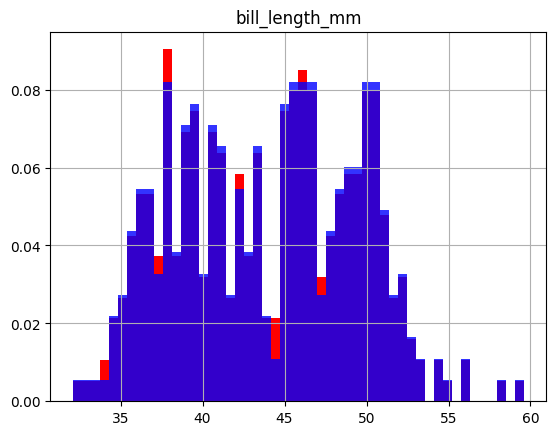

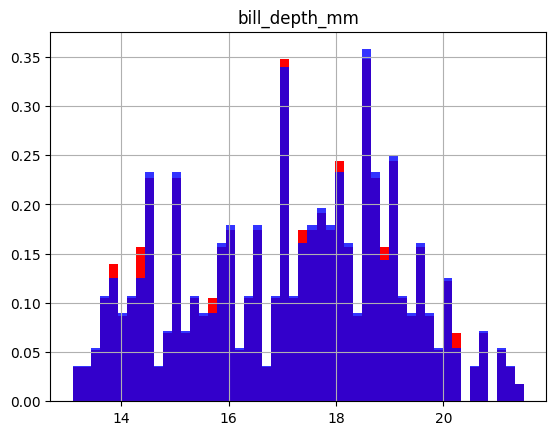

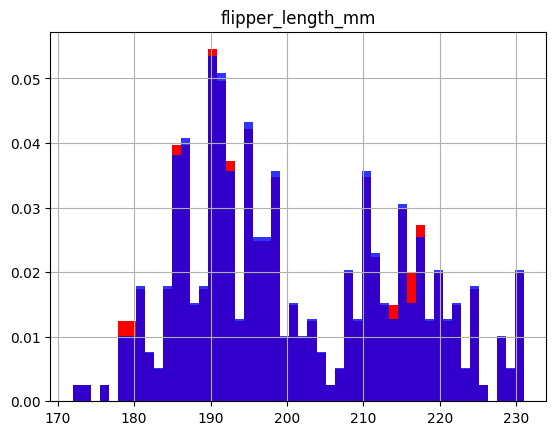

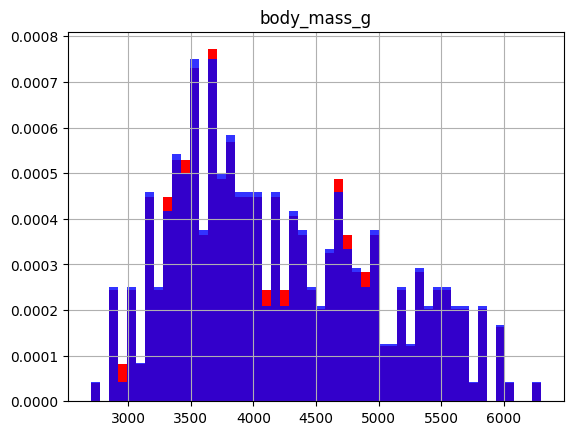

In [114]:
for i in range(0,4):
  fig = plt.figure()
  ax = fig.add_subplot(111)

  # original data
  df.iloc[:,i].hist(bins=50, ax=ax, density=True, color='red')
  plt.title(c[i])
  # data after cca, the argument alpha makes the color transparent, so we can
  # see the overlay of the 2 distributions
  new_df.iloc[:,i].hist(bins=50, ax=ax, color='blue', density=True, alpha=0.8)

AttributeError: Rectangle.set() got an unexpected keyword argument 'kde'

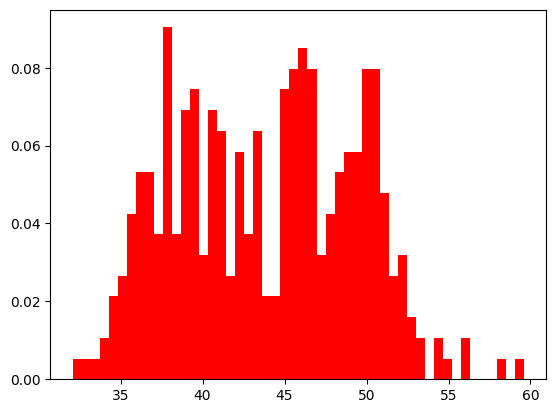

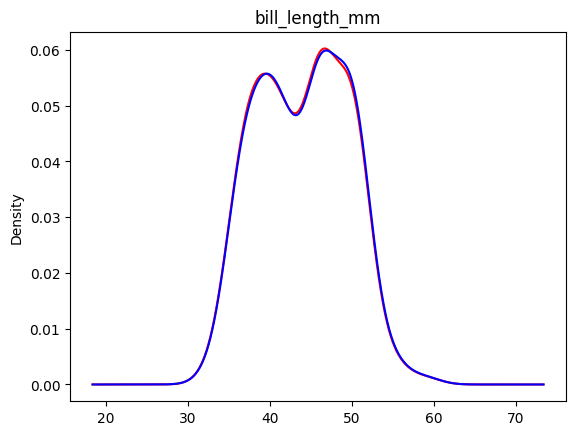

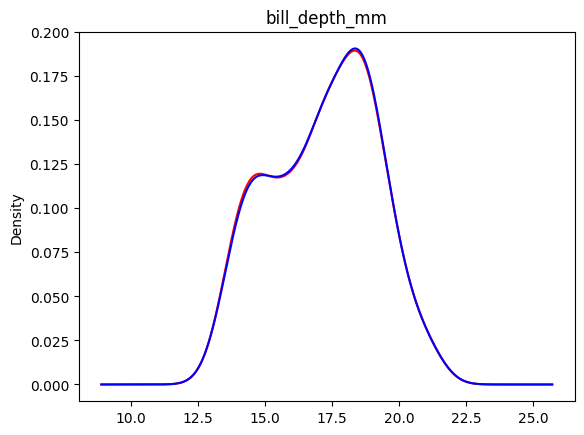

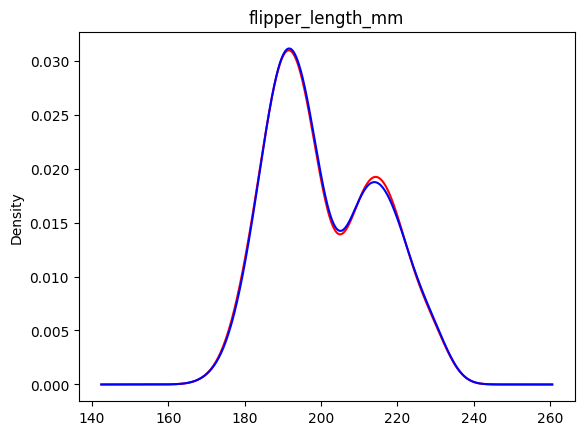

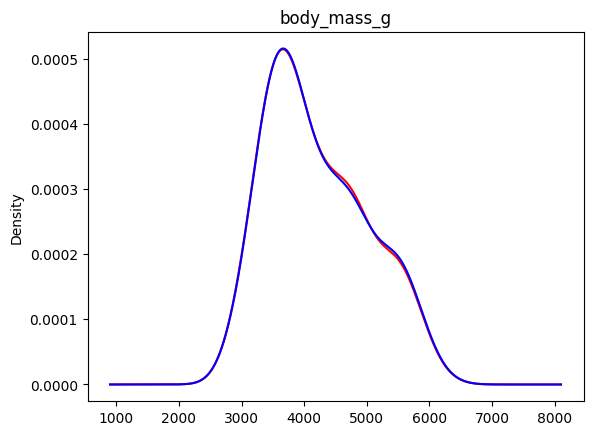

In [117]:
for i in range(0,4):
  fig = plt.figure()
  ax = fig.add_subplot(111)

  # original data
  df.iloc[:,i].plot.density(color='red')
  plt.title(c[i])
  # data after cca, the argument alpha makes the color transparent, so we can
  # see the overlay of the 2 distributions
  new_df.iloc[:,i].plot.density(color='blue')

In [123]:
for i in range (0,3):

  temp = pd.concat([
              # percentage of observations per category, original data
              df.iloc[i].value_counts() / len(df),

              # percentage of observations per category, cca data
              new_df.iloc[i].value_counts() / len(new_df)
          ],
          axis=1)
